# Serial DEG analysis

In [1]:
import sys
sys.path.insert(0, '../lib')

In [32]:
import os
import pandas as pd

import seaborn as sns

import common_data

In [3]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200
pd.options.display.max_colwidth = 1000
%config InlineBackend.figure_format = "retina"

In [4]:
def sanitize_name(name):
    return name.replace(' ', '_').replace('*', '').replace(';', '_and').replace('/', '_')

In [ ]:
BASE = common_data.DATA / '05_pseudobulk/40a_serial'

In [ ]:
df = pd.read_csv(BASE / '_group_labels.csv')

In [8]:
num = common_data.get_sc_numerical_covariates()
cat = common_data.get_sc_categorical_covariates()
sc_labels = pd.read_csv(common_data.SC_LABELS, index_col=0)
ehr = pd.read_csv(common_data.CLINICAL, index_col=0)

# Difference between baselines

- time on vent
- external transfer
- gap to the next BAL
- immunocompromized

In [12]:
df = df.loc[df.timepoint.eq('first') & df.group.ne('discard')].copy()

In [29]:
df['Immunocompromised'] = cat.Immunocompromised_flag[df.bal_barcode.values].values
df.Immunocompromised = df.Immunocompromised.astype(str)

In [30]:
df.groupby('group').Immunocompromised.value_counts().reset_index(name='count')

,group,Immunocompromised,count
0,no_vap,0,14
1,no_vap,1,2
2,vap,0,6
3,vap,1,4


In [31]:
df['days_on_ventilator'] = num.days_on_ventilator[df.bal_barcode.values].values

/tmp/ipykernel_2365897/2886186555.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_2365897/2886186555.py:7: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


<Axes: xlabel='group', ylabel='days_on_ventilator'>

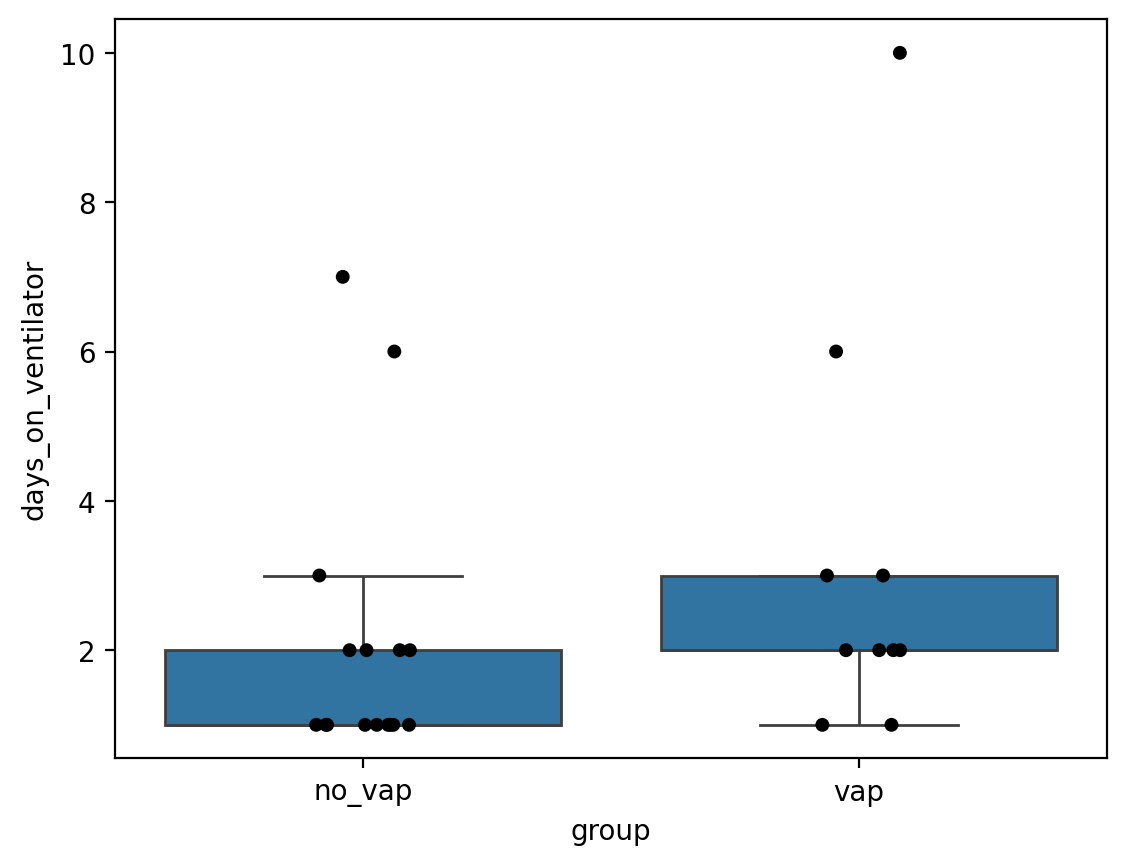

In [36]:
sns.boxplot(
    data=df,
    x='group',
    y='days_on_ventilator',
    showfliers=False
)
sns.stripplot(
    data=df,
    x='group',
    y='days_on_ventilator',
    palette=['k']
)

In [38]:
df['external'] = sc_labels.set_index('bal_barcode').External_transfer_flag[df.bal_barcode.values].values

In [39]:
df.groupby('group').external.value_counts().reset_index(name='count')

,group,external,count
0,no_vap,0.0,12
1,no_vap,1.0,4
2,vap,0.0,8
3,vap,1.0,2


In [ ]:
df = pd.read_csv(BASE / '_group_labels.csv')

In [45]:
gaps = df.loc[df.group.ne('discard')].groupby('pair_id').apply(
    lambda x: pd.Series([
        int(x.bal_barcode.iat[1][-2:]) - int(x.bal_barcode.iat[0][-2:]),
        x.group.iat[0]
    ])
)

In [51]:
gaps = gaps.rename(columns={0: 'n_days', 1: 'group'})

/tmp/ipykernel_2365897/3675481250.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_2365897/3675481250.py:7: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


<Axes: xlabel='group', ylabel='n_days'>

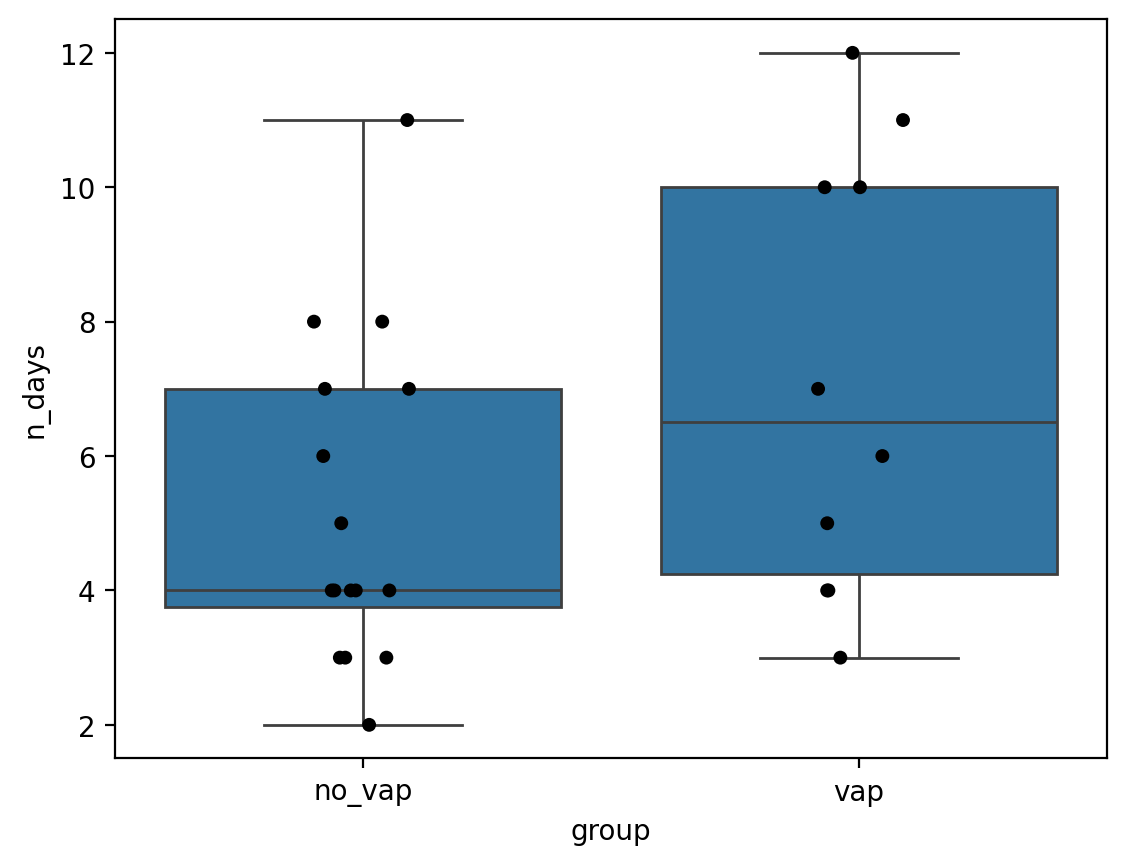

In [53]:
sns.boxplot(
    data=gaps,
    x='group',
    y='n_days',
    showfliers=False
)
sns.stripplot(
    data=gaps,
    x='group',
    y='n_days',
    palette=['k']
)